Dataset loaded successfully!
Number of rows: 20
Number of columns: 12

--- FIRST 5 ROWS ---
   Invoice_ID Branch       City Customer_Type  Gender        Product_Line  \
0       10001      A  Bangalore        Member  Female  Food and Beverages   
1       10002      B  Bangalore        Normal    Male         Electronics   
2       10003      C     Mysore        Member  Female   Health and Beauty   
3       10004      A  Bangalore        Normal  Female            Clothing   
4       10005      B     Mysore        Member    Male  Food and Beverages   

   Unit_Price  Quantity   Total       Date      Payment  Rating  
0        45.5         3  143.33 2026-01-05      Ewallet     8.5  
1        80.0         2  168.00 2026-01-07         Cash     7.2  
2        35.0         5  183.75 2026-01-10  Credit Card     9.1  
3        60.0         2  126.00 2026-01-12         Cash     7.8  
4        25.0         6  157.50 2026-01-15      Ewallet     8.9  

--- LAST 5 ROWS ---
    Invoice_ID Branch       

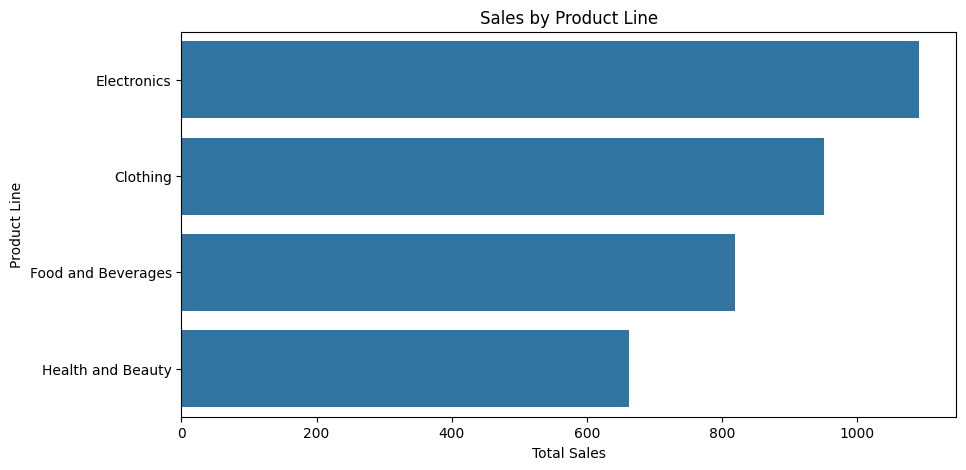

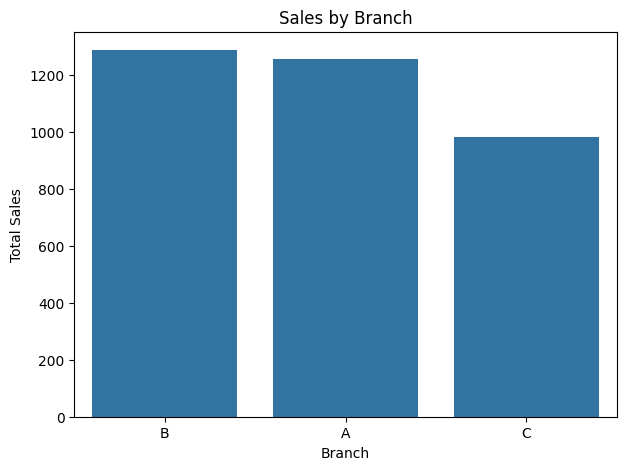

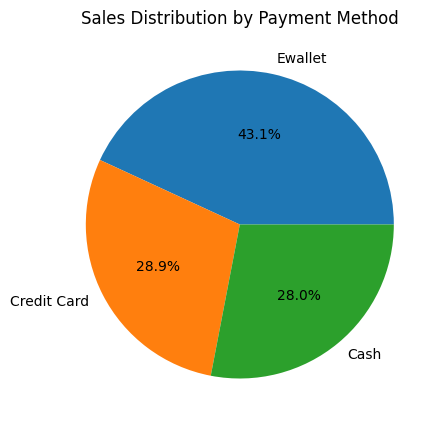

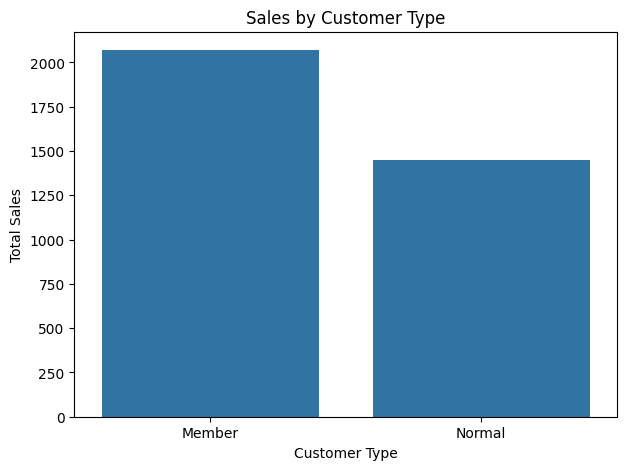

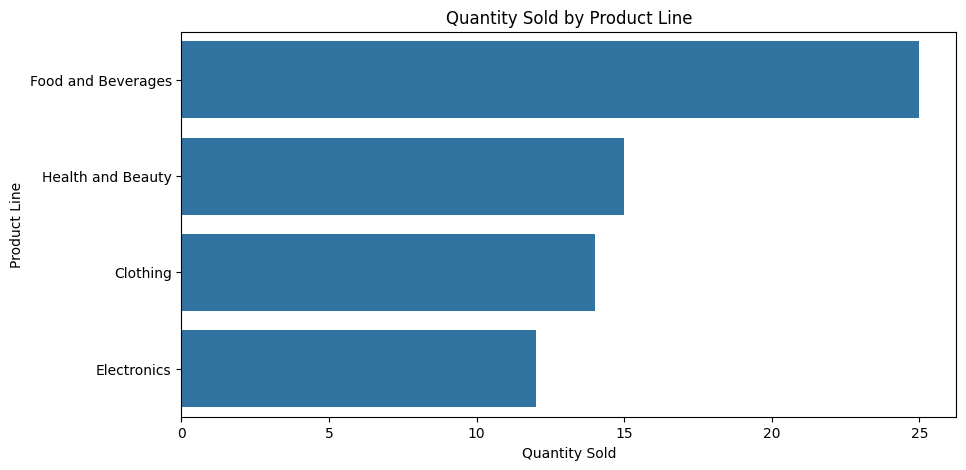

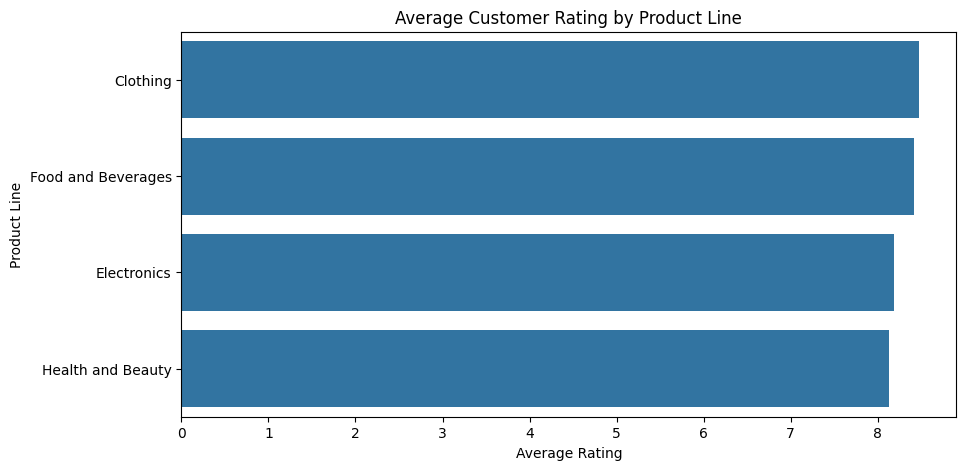

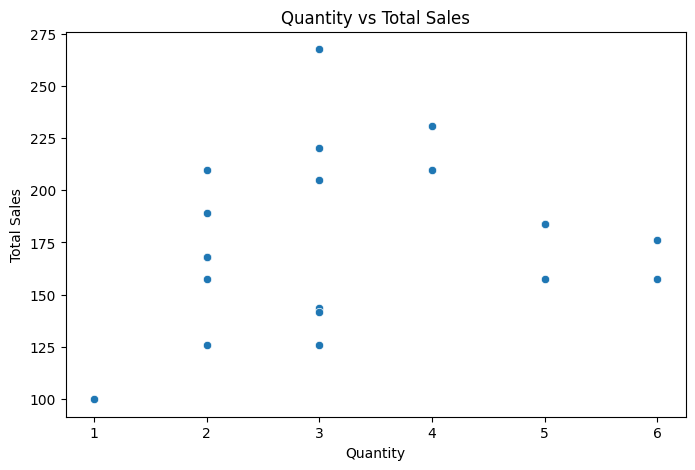

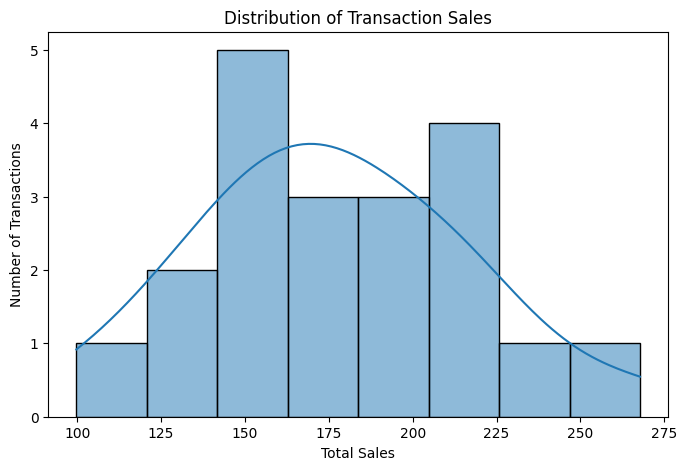


       KEY FINDINGS
Best-selling product category: Electronics | Sales: 1092.0
Highest-sales branch: B | Sales: 1286.25
Most frequently used payment method: Ewallet
Customer type generating the most sales: Member
Highest-rated product category: Clothing

PROJECT COMPLETED SUCCESSFULLY!

Cleaned files created:
1. cleaned_supermarket_sales.xlsx
2. cleaned_supermarket_sales.csv


In [8]:

# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "/content/supermarket_sales_python_project.xlsx"

data = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

# ============================================================
# 3. VIEW THE DATA
# ============================================================

print("\n--- FIRST 5 ROWS ---")
print(data.head())

print("\n--- LAST 5 ROWS ---")
print(data.tail())

# ============================================================
# 4. UNDERSTAND THE DATA
# ============================================================

print("\n--- DATASET SHAPE ---")
print(data.shape)

print("\n--- COLUMN NAMES ---")
print(data.columns.tolist())

print("\n--- DATA TYPES ---")
print(data.dtypes)

print("\n--- DATASET INFORMATION ---")
data.info()

# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n--- MISSING VALUES ---")
print(data.isnull().sum())

# ============================================================
# 6. CHECK DUPLICATES
# ============================================================

print("\n--- DUPLICATE ROWS ---")
print("Number of duplicates:", data.duplicated().sum())

# Remove duplicates if any exist
data = data.drop_duplicates()

# ============================================================
# 7. CHECK BASIC STATISTICS
# ============================================================

print("\n--- STATISTICAL SUMMARY ---")
print(data.describe())

# ============================================================
# 8. CONVERT DATE COLUMN
# ============================================================

data["Date"] = pd.to_datetime(data["Date"])

# Create useful date columns
data["Month"] = data["Date"].dt.month_name()
data["Month_Number"] = data["Date"].dt.month

# ============================================================
# 9. CREATE ADDITIONAL CALCULATED COLUMNS
# ============================================================

# Revenue per item
data["Revenue_Per_Item"] = data["Total"] / data["Quantity"]

# Create a simple sales category
data["Sales_Category"] = pd.cut(
    data["Total"],
    bins=[0, 150, 200, float("inf")],
    labels=["Low", "Medium", "High"]
)

print("\n--- UPDATED DATA ---")
print(data.head())

# ============================================================
# 10. KEY BUSINESS METRICS
# ============================================================

total_sales = data["Total"].sum()
average_sales = data["Total"].mean()
total_quantity = data["Quantity"].sum()
total_transactions = data["Invoice_ID"].nunique()
average_rating = data["Rating"].mean()

print("\n==============================")
print("       KEY METRICS")
print("==============================")

print("Total Sales:", round(total_sales, 2))
print("Average Transaction Value:", round(average_sales, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Transactions:", total_transactions)
print("Average Customer Rating:", round(average_rating, 2))

# ============================================================
# 11. SALES BY PRODUCT LINE
# ============================================================

product_sales = (
    data.groupby("Product_Line")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- SALES BY PRODUCT LINE ---")
print(product_sales)

# ============================================================
# 12. SALES BY BRANCH
# ============================================================

branch_sales = (
    data.groupby("Branch")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- SALES BY BRANCH ---")
print(branch_sales)

# ============================================================
# 13. SALES BY CITY
# ============================================================

city_sales = (
    data.groupby("City")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- SALES BY CITY ---")
print(city_sales)

# ============================================================
# 14. SALES BY CUSTOMER TYPE
# ============================================================

customer_sales = (
    data.groupby("Customer_Type")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- SALES BY CUSTOMER TYPE ---")
print(customer_sales)

# ============================================================
# 15. SALES BY PAYMENT METHOD
# ============================================================

payment_sales = (
    data.groupby("Payment")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- SALES BY PAYMENT METHOD ---")
print(payment_sales)

# ============================================================
# 16. QUANTITY SOLD BY PRODUCT
# ============================================================

product_quantity = (
    data.groupby("Product_Line")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("\n--- QUANTITY SOLD BY PRODUCT ---")
print(product_quantity)

# ============================================================
# 17. AVERAGE RATING BY PRODUCT
# ============================================================

product_rating = (
    data.groupby("Product_Line")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\n--- AVERAGE RATING BY PRODUCT ---")
print(product_rating.round(2))

# ============================================================
# 18. MONTHLY SALES
# ============================================================

monthly_sales = (
    data.groupby(["Month_Number", "Month"])["Total"]
    .sum()
    .sort_index()
)

print("\n--- MONTHLY SALES ---")
print(monthly_sales)

# ============================================================
# 19. TOP TRANSACTIONS
# ============================================================

top_transactions = data.sort_values(
    "Total",
    ascending=False
).head(5)

print("\n--- TOP 5 TRANSACTIONS ---")
print(
    top_transactions[
        ["Invoice_ID", "Product_Line", "Quantity", "Total"]
    ]
)

# ============================================================
# 20. CORRELATION ANALYSIS
# ============================================================

print("\n--- CORRELATION ---")

correlation = data[
    ["Unit_Price", "Quantity", "Total", "Rating"]
].corr()

print(correlation.round(2))

# ============================================================
# 21. VISUALIZATION 1
# SALES BY PRODUCT LINE
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title("Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")

plt.show()

# ============================================================
# 22. VISUALIZATION 2
# SALES BY BRANCH
# ============================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values
)

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.show()

# ============================================================
# 23. VISUALIZATION 3
# SALES BY PAYMENT METHOD
# ============================================================

plt.figure(figsize=(7, 5))

payment_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Payment Method")
plt.ylabel("")

plt.show()

# ============================================================
# 24. VISUALIZATION 4
# SALES BY CUSTOMER TYPE
# ============================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    x=customer_sales.index,
    y=customer_sales.values
)

plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.show()

# ============================================================
# 25. VISUALIZATION 5
# QUANTITY BY PRODUCT
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=product_quantity.values,
    y=product_quantity.index
)

plt.title("Quantity Sold by Product Line")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Line")

plt.show()

# ============================================================
# 26. VISUALIZATION 6
# RATING BY PRODUCT
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=product_rating.values,
    y=product_rating.index
)

plt.title("Average Customer Rating by Product Line")
plt.xlabel("Average Rating")
plt.ylabel("Product Line")

plt.show()

# ============================================================
# 27. VISUALIZATION 7
# QUANTITY VS TOTAL SALES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="Quantity",
    y="Total"
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()

# ============================================================
# 28. VISUALIZATION 8
# SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data["Total"],
    bins=8,
    kde=True
)

plt.title("Distribution of Transaction Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of Transactions")

plt.show()

# ============================================================
# 29. FIND BEST PERFORMING PRODUCT
# ============================================================

best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("\n==============================")
print("       KEY FINDINGS")
print("==============================")

print(
    "Best-selling product category:",
    best_product,
    "| Sales:",
    round(best_product_sales, 2)
)

# ============================================================
# 30. FIND BEST BRANCH
# ============================================================

best_branch = branch_sales.idxmax()
best_branch_sales = branch_sales.max()

print(
    "Highest-sales branch:",
    best_branch,
    "| Sales:",
    round(best_branch_sales, 2)
)

# ============================================================
# 31. MOST USED PAYMENT METHOD
# ============================================================

most_used_payment = data["Payment"].value_counts().idxmax()

print(
    "Most frequently used payment method:",
    most_used_payment
)

# ============================================================
# 32. BEST CUSTOMER TYPE BY SALES
# ============================================================

best_customer_type = customer_sales.idxmax()

print(
    "Customer type generating the most sales:",
    best_customer_type
)

# ============================================================
# 33. HIGHEST RATED PRODUCT
# ============================================================

highest_rated_product = product_rating.idxmax()

print(
    "Highest-rated product category:",
    highest_rated_product
)

# ============================================================
# 34. EXPORT CLEANED DATA
# ============================================================

data.to_excel(
    "cleaned_supermarket_sales.xlsx",
    index=False
)

data.to_csv(
    "cleaned_supermarket_sales.csv",
    index=False
)

print("\n====================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("====================================")

print("\nCleaned files created:")
print("1. cleaned_supermarket_sales.xlsx")
print("2. cleaned_supermarket_sales.csv")